In [102]:
from keras.datasets import fashion_mnist as fm;
from keras.utils import to_categorical
from keras import layers,models,regularizers
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

In [103]:
# สร้าง List ของ Class label เพื่อทำ Word indice
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [104]:
(train_x,train_y) , (test_x,test_y) = fm.load_data()

In [105]:
# จากเดิม (MLP)
# train_x = train_x.reshape((train_x.shape[0], 28*28)).astype('float') / 255

# เปลี่ยนเป็น (CNN)
train_x = train_x.reshape((train_x.shape[0], 28, 28, 1)).astype('float') / 255
test_x = test_x.reshape((test_x.shape[0], 28, 28, 1)).astype('float') / 255

# ถ้ามีรูป Custom ของตัวเอง ก็ต้อง reshape เป็น (1, 28, 28, 1) เช่นกัน

In [106]:
val_x = train_x[40000:]
val_y = train_y[40000:]

train_x = train_x[:40000]
train_y = train_y[:40000]

In [107]:
def buildCNNModel():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'), # เพิ่มจำนวน Neuron
        layers.Dropout(0.5),                  # เพิ่ม Dropout ป้องกัน Overfitting
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam', # Adam มักจะให้ผลดีกว่า RMSprop ในงานทั่วไป
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [108]:
model = buildCNNModel()

In [109]:
history = model.fit(train_x, train_y, 
                    epochs=20, 
                    batch_size=64, 
                    validation_data=(val_x, val_y))

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7591 - loss: 0.6637 - val_accuracy: 0.8481 - val_loss: 0.4166
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8440 - loss: 0.4348 - val_accuracy: 0.8730 - val_loss: 0.3452
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8654 - loss: 0.3757 - val_accuracy: 0.8824 - val_loss: 0.3157
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8759 - loss: 0.3415 - val_accuracy: 0.8807 - val_loss: 0.3155
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8834 - loss: 0.3185 - val_accuracy: 0.8953 - val_loss: 0.2823
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8925 - loss: 0.2952 - val_accuracy: 0.8968 - val_loss: 0.2785
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8985 - loss: 0.2782 - val_accuracy: 0.8939 - val_loss: 0.2826
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9035 - loss: 0.2642 - val_accuracy: 0.

In [110]:
def plot(history,name="") :
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.figure(figsize=(15,7))
    
    plt.subplot(1,2,1)
    plt.plot(epochs,loss,'r',label='Training loss')
    plt.plot(epochs,val_loss,'b',label='Validation loss')
    plt.title('Training and Validation Loss '+ name)
    plt.grid(True)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1,2,2)
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    epochs = range(1 , len(accuracy) + 1)
    plt.plot(epochs,accuracy,'r',label='Training Accuracy')
    plt.plot(epochs,val_accuracy,'b',label='Validation Accuracy')
    plt.title('Training and Validation Accuracy ' + name)
    plt.grid(True)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
    print(f"min val_loss : {min(val_loss)}")
    print(f"max val_acc : {max(val_accuracy)}")
    print(f"Latest val_loss : {val_loss[len(val_loss)-1]}")
    print(f"Latest val_acc : {val_accuracy[len(val_accuracy)-1]}")

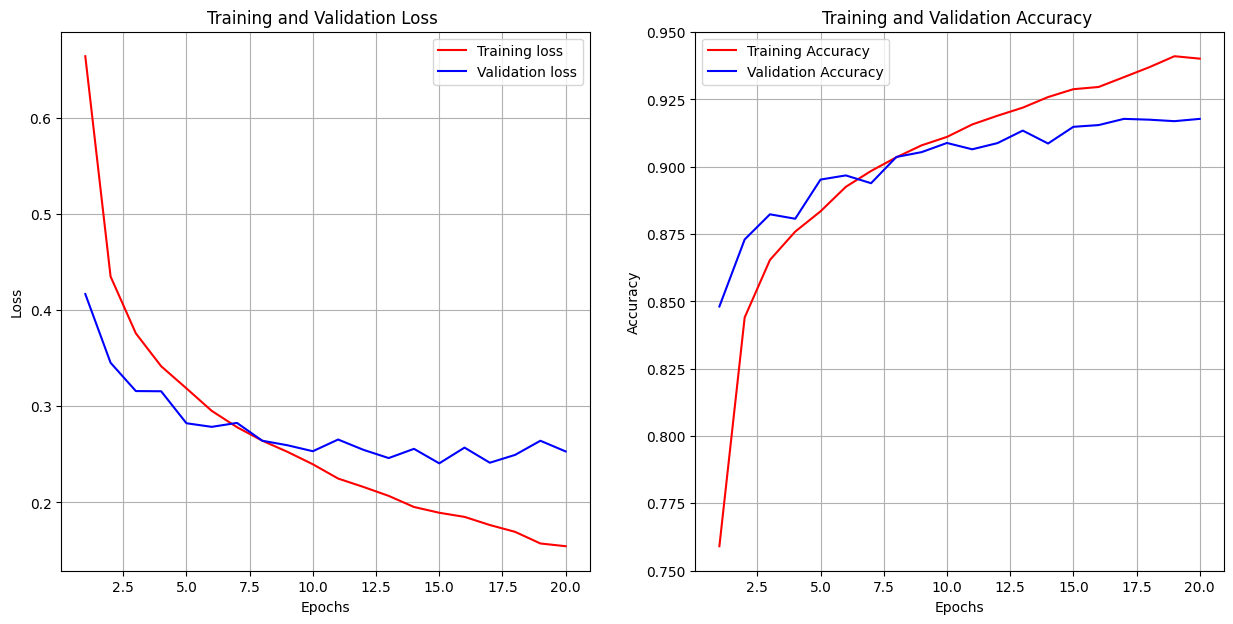

min val_loss : 0.24060697853565216
max val_acc : 0.9178000092506409
Latest val_loss : 0.2529706060886383
Latest val_acc : 0.9178000092506409
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9093 - loss: 0.2729
Evaluate Loss : 0.2729024291038513 , Evaluate Acc : 0.9093000292778015


In [111]:
# สั่ง plot graph 
plot(history)
loss , acc = model.evaluate(test_x,test_y)
print(f"Evaluate Loss : {loss} , Evaluate Acc : {acc}")

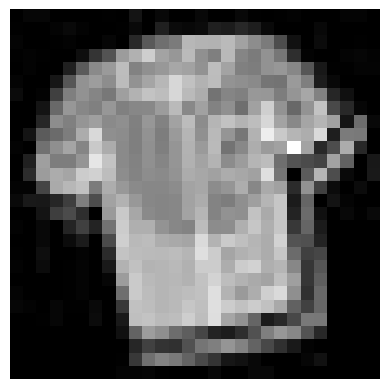

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predicted : Shirt
ความมั่นใจ: 42.52%


In [112]:
filename = f"Shirt.jpg"
img = load_img(filename,color_mode='grayscale',target_size=(28,28))

img_array = img_to_array(img)
img_array = 255.0 - img_array

img_array = img_array.reshape((1,28,28,1)).astype('float32')/255.0

plt.imshow(img_array.reshape(28,28) , cmap='gray')
plt.axis('off')
plt.show()

prediction = history.model.predict(img_array)
predicted_digit = np.argmax(prediction)

print(f"Predicted : {class_names[predicted_digit]}")
print(f"ความมั่นใจ: {prediction[0][predicted_digit] * 100:.2f}%")

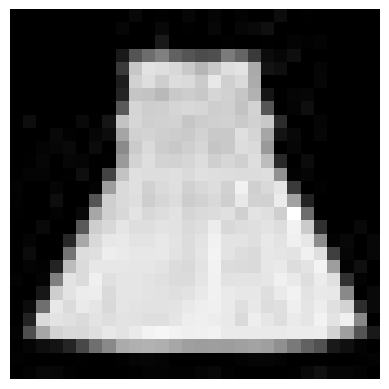

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Predicted : Dress
ความมั่นใจ: 56.26%


In [113]:
filename = f"Dress.jpg"
img = load_img(filename,color_mode='grayscale',target_size=(28,28))

img_array = img_to_array(img)
img_array = 255.0 - img_array

img_array = img_array.reshape((1,28,28,1)).astype('float32')/255.0

plt.imshow(img_array.reshape(28,28) , cmap='gray')
plt.axis('off')
plt.show()

prediction = history.model.predict(img_array)
predicted_digit = np.argmax(prediction)

print(f"Predicted : {class_names[predicted_digit]}")
print(f"ความมั่นใจ: {prediction[0][predicted_digit] * 100:.2f}%")

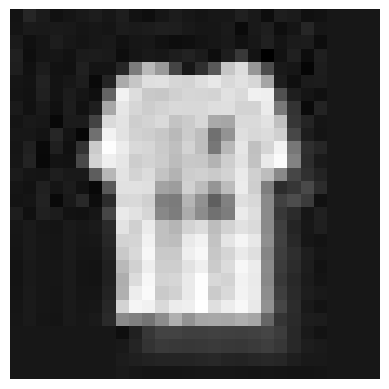

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Predicted : Bag
ความมั่นใจ: 88.12%


In [114]:
filename = f"T-shirt.jpg"
img = load_img(filename,color_mode='grayscale',target_size=(28,28))

img_array = img_to_array(img)
img_array = 255.0 - img_array

img_array = img_array.reshape((1,28,28,1)).astype('float32')/255.0

plt.imshow(img_array.reshape(28,28) , cmap='gray')
plt.axis('off')
plt.show()

prediction = history.model.predict(img_array)
predicted_digit = np.argmax(prediction)

print(f"Predicted : {class_names[predicted_digit]}")
print(f"ความมั่นใจ: {prediction[0][predicted_digit] * 100:.2f}%")